In [2]:
import numpy as np

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [ ]:
train = pd.read_csv('Train.csv')  
test = pd.read_csv('Test.csv')  
ss = pd.read_csv('SampleSubmission.csv')  
variables = pd.read_csv('VariableDefinitions.csv')  

# Display first few rows to understand structure
print(" Training Data Preview:")
display(train.head())

print(" Variable Definitions Preview:")
display(variables.head())

 Training Data Preview:


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


 Variable Definitions Preview:


,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"


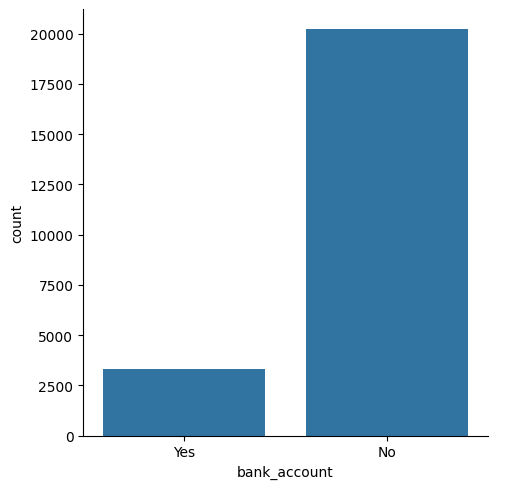

In [7]:
# Explore Target distribution
sns.catplot(x="bank_account", kind="count", data=train)

In [9]:
#show some information about the dataset
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 23524 non-null  str  
 1   year                    23524 non-null  int64
 2   uniqueid                23524 non-null  str  
 3   bank_account            23524 non-null  str  
 4   location_type           23524 non-null  str  
 5   cellphone_access        23524 non-null  str  
 6   household_size          23524 non-null  int64
 7   age_of_respondent       23524 non-null  int64
 8   gender_of_respondent    23524 non-null  str  
 9   relationship_with_head  23524 non-null  str  
 10  marital_status          23524 non-null  str  
 11  education_level         23524 non-null  str  
 12  job_type                23524 non-null  str  
dtypes: int64(3), str(10)
memory usage: 2.3 MB
None


In [10]:
#import preprocessing module
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Initialize LabelEncoder globally
le = LabelEncoder()

In [ ]:
# Map target 
train['bank_account'] = train['bank_account'].map({'Yes': 1, 'No': 0})
y_train = train['bank_account']

In [13]:
X_train_raw = train.drop(['bank_account'], axis=1)
X_test_raw = test.copy()

In [14]:
X_train_raw['is_train'] = 1
X_test_raw['is_train'] = 0
combined = pd.concat([X_train_raw, X_test_raw], axis=0).reset_index(drop=True)

In [ ]:
def engineer_and_preprocess(data):
    
    df = data.copy()
    
    #FEATURE ENGINEERING
    
    # Feature 1: Financial Dependency Proxy
    # A younger individual in a massive household has different asset leverage than an older household head.
    df['age_per_household_member'] = df['age_of_respondent'] / df['household_size']
    
    # Feature 2: Ordinal Education Level
    # Standard one-hot encoding treats education levels as entirely independent categories.
    # Mapping them hierarchically helps XGBoost find the linear progression of academic attainment.
    edu_map = {
        'No formal education': 0, 'Other/Dont know/RTA': 1, 'Primary education': 2, 
        'Secondary education': 3, 'Vocational/Specialised training': 4, 'Tertiary education': 5
    }
    df['education_ordinal'] = df['education_level'].map(edu_map)
    
    # Feature 3: Is the Decision Maker?
    df['is_household_head'] = (df['relationship_with_head'] == 'Head of Household').astype(int)
    
    # Feature 4: Formal Income & Communication Interaction
    # Combining phone access with structured employment isolates the demographic most likely to require digital banking.
    df['phone_and_formal_job'] = ((df['cellphone_access'] == 'Yes') & 
                                  (df['job_type'].isin(['Formally employed Government', 'Formally employed Private']))).astype(int)
    
    
    
    # Binary Categorical Conversions via LabelEncoder
    df["location_type"] = le.fit_transform(df["location_type"])
    df["cellphone_access"] = le.fit_transform(df["cellphone_access"])
    df["gender_of_respondent"] = le.fit_transform(df["gender_of_respondent"])
    
    # Multi-class Categorical Features for One Hot Encoding
    categ = ["relationship_with_head", "marital_status", "education_level", "job_type", "country"]
    df = pd.get_dummies(df, prefix_sep="_", columns=categ)
    
    
    df = df.drop(["uniqueid"], axis=1)
    
    return df

In [ ]:
processed_combined = engineer_and_preprocess(combined)

# Separate back into Train and Test data frames
processed_train = processed_combined[processed_combined['is_train'] == 1].drop(['is_train'], axis=1)
processed_test = processed_combined[processed_combined['is_train'] == 0].drop(['is_train'], axis=1)

print("Processed Train Shape:", processed_train.shape)
print("Processed Test Shape:", processed_test.shape)

Processed Train Shape: (23524, 41)
Processed Test Shape: (10086, 41)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBClassifier

In [18]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    processed_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [19]:
xgb_model = XGBClassifier(
    n_estimators=180,
    learning_rate=0.06,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mae'
)

In [ ]:
xgb_model.fit(X_train_split, y_train_split)

# Evaluate validation error
val_predictions = xgb_model.predict(X_val_split)
new_mae = mean_absolute_error(y_val_split, val_predictions)

print(f"Previous Baseline Error: 0.1120")
print(f"New Preprocessed & Engineered Validation Error: {new_mae:.4f}")

Previous Baseline Error: 0.1120
New Preprocessed & Engineered Validation Error: 0.1114


In [21]:
from sklearn.model_selection import GridSearchCV

In [23]:
param_grid = {'min_child_weighth': [1, 5, 10],
        'gamma': [0.5, 1],
        'subsample': [0.6, 0.8, 1.0],
        'max_depth': [3, 5]
        }

In [24]:
my_xgb_model = GridSearchCV(xgb_model, param_grid,n_jobs=-1,verbose=2,cv=5)
my_xgb_model.fit(X_train_split, y_train_split)
print(my_xgb_model.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\user\dsenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:15:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_child_weighth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'gamma': 1, 'max_depth': 5, 'min_child_weighth': 1, 'subsample': 0.6}


In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [27]:
# fit by setting best parameters and Evaluate model
xgb_model2 = XGBClassifier(min_child_weight=1, gamma=1, subsample=0.6, max_depth=5)

In [28]:
xgb_model2.fit(X_train_split, y_train_split)
y_pred = xgb_model2.predict(X_val_split)

In [29]:
new_mae = mean_absolute_error(y_val_split, y_pred)

In [30]:
print(f"New Preprocessed & Engineered Validation Error: {new_mae:.4f}")

New Preprocessed & Engineered Validation Error: 0.1129


In [31]:
# Get the predicted result for the test Data
test.bank_account = xgb_model.predict(processed_test)

C:\Users\user\AppData\Local\Temp\ipykernel_16340\4179094782.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  test.bank_account = xgb_model.predict(processed_test)


In [32]:
# Get the predicted result for the test Data
test.bank_account2 = xgb_model2.predict(processed_test)

C:\Users\user\AppData\Local\Temp\ipykernel_16340\2332656821.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  test.bank_account2 = xgb_model2.predict(processed_test)


In [33]:
submission = pd.DataFrame({"uniqueid": test["uniqueid"] + " x " + test["country"],
                           "bank_account": test.bank_account})

In [34]:
submission.to_csv('second_submission.csv', index = False)

In [35]:
submission2 = pd.DataFrame({"uniqueid": test["uniqueid"] + " x " + test["country"],
                           "bank_account": test.bank_account2})

In [36]:
submission2.to_csv('third_submission.csv', index = False)